In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot

from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import GlobalMaxPooling1D
from keras.layers import LSTM
from keras.layers import Embedding
from sklearn.model_selection import train_test_split
from keras_preprocessing.text import Tokenizer


In [3]:
movie_reviews = pd.read_csv("IMDB Dataset.csv")


### Dataset dimension

In [4]:
movie_reviews.shape

(50000, 2)

### NULL values

In [5]:
movie_reviews.isnull().sum()

review       0
sentiment    0
dtype: int64

### 5 first lines of the dataset

In [6]:
movie_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Check if the dataset is balanced

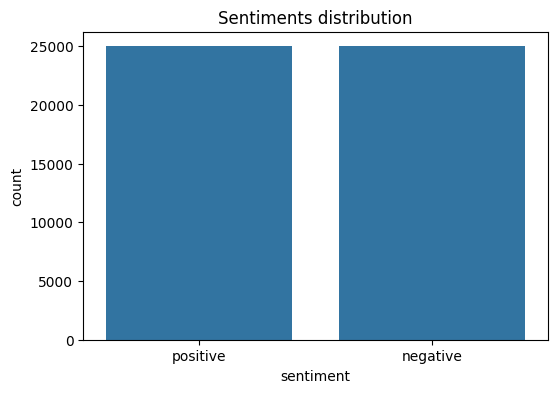

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=movie_reviews)
plt.title("Sentiments distribution")
plt.show()

=> Dataset is balanced: 25000 potive and 25000 negative

### Print the 4th review

In [8]:
movie_reviews['review'][3]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

=> On remarque : balises HTML (<br />), ponctuation, chiffres, caractères spéciaux

## PRÉTRAITEMENT DES DONNÉES

In [9]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    """Supprime toutes les balises HTML du texte."""
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    """
    Nettoie une phrase :
    1) Supprime les balises HTML
    2) Supprime la ponctuation et les chiffres (garde uniquement les lettres)
    3) Supprime les caractères isolés (ex: 's', 'a' seuls)
    4) Supprime les espaces multiples
    """
    sentence = remove_tags(sen)
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence

In [10]:
# Appliquer le prétraitement sur toutes les reviews
X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

### Afficher le 4ème review après prétraitement


In [11]:
X[3]

'Basically there a family where little boy Jake thinks there a zombie in his closet his parents are fighting all the time This movie is slower than soap opera and suddenly Jake decides to become Rambo and kill the zombie OK first of all when you re going to make film you must Decide if its thriller or drama As drama the movie is watchable Parents are divorcing arguing like in real life And then we have Jake with his closet which totally ruins all the film expected to see BOOGEYMAN similar movie and instead watched drama with some meaningless thriller spots out of just for the well playing parents descent dialogs As for the shots with Jake just ignore them '

### Conversion des etiquettes

In [12]:
y = movie_reviews['sentiment']
y = np.array(list(map(lambda x: 1 if x == "positive" else 0, y)))

In [13]:
np.unique(y, return_counts=True)

(array([0, 1]), array([25000, 25000], dtype=int64))

### Division train and test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

## Embedding Layer

In [15]:
from keras_preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test  = tokenizer.texts_to_sequences(X_test)

In [16]:
vocab_size = len(tokenizer.word_index) + 1
vocab_size

92547

In [17]:
from keras.preprocessing.sequence import pad_sequences
maxlen = 100
X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test  = pad_sequences(X_test,  padding='post', maxlen=maxlen)

In [18]:
print(f"Shape X_train: {X_train.shape}") 
print(f"Shape X_test : {X_test.shape}")

Shape X_train: (40000, 100)
Shape X_test : (10000, 100)


In [19]:
from numpy import asarray, zeros

embeddings_dictionary = dict()

glove_file = open("glove.6B.100d.txt", encoding="utf8")
for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary[word] = vector_dimensions
glove_file.close()

In [20]:
print(f"Nombre de mots dans GloVe: {len(embeddings_dictionary)}")


Nombre de mots dans GloVe: 400000


In [21]:
# Création de la matrice d'embeddings (vocab_size x 100)
embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (92547, 100)
